In [1]:
# 01_data_preparation.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
import spacy


# Load
df = pd.read_csv("../data/train.csv")

# Preview
df.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [2]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [3]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [5]:
df.shape

(159571, 8)

## Dataset Overview
- The dataset contains 159,571 comments and 8 columns.
- There are no missing values in the text or label columns.
- The key input variable is comment_text, and the six output variables are binary toxicity labels:
    - toxic, severe_toxic, obscene, threat, insult, identity_hate.
- Each label represents a specific type of toxic behavior, and multiple labels can apply to a single comment.
* This is a multi-label classification problem; a single comment can belong to multiple toxic categories.

In [6]:
# Look at the total count of each label
df.iloc[:, 2:].sum().sort_values(ascending=False)


toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

## Distribution of Labels
- The dataset is highly imbalanced, most comments are either not toxic or only mildly toxic. Rare labels like threat and identity_hate will need special handling (e.g., class weighting or oversampling).

Text(0.5, 1.0, 'Class Distribution: Safe vs Flagged Content')

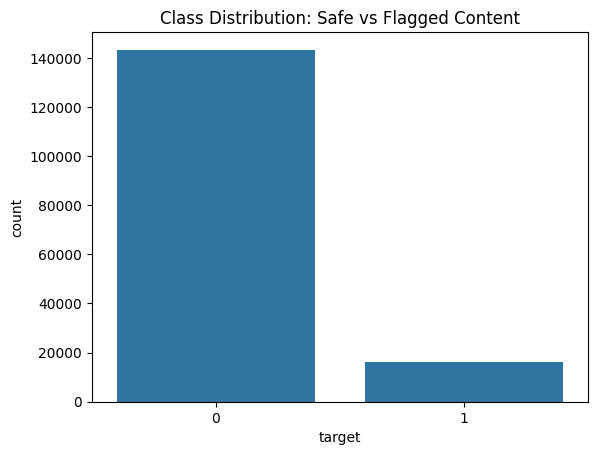

In [7]:
# Basic label analysis
df['target'] = (df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum(axis=1) > 0).astype(int)
sns.countplot(x='target', data=df)
plt.title("Class Distribution: Safe vs Flagged Content")

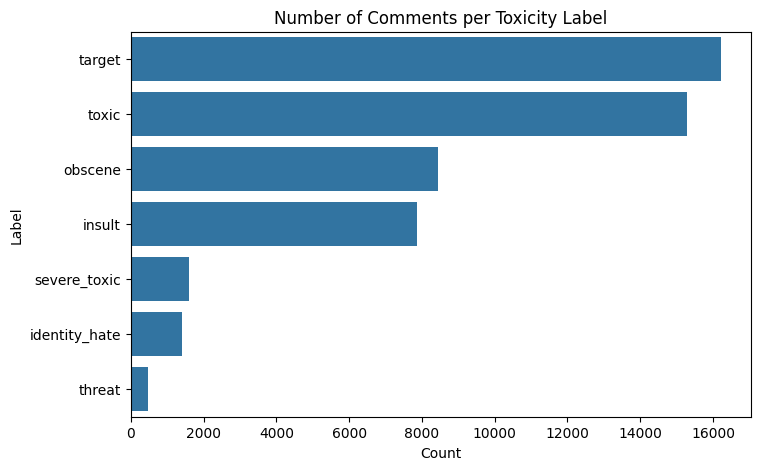

In [8]:
# Get label counts
label_counts = df.iloc[:, 2:].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, orient="h")

plt.title("Number of Comments per Toxicity Label")
plt.xlabel("Count")
plt.ylabel("Label")
plt.show()

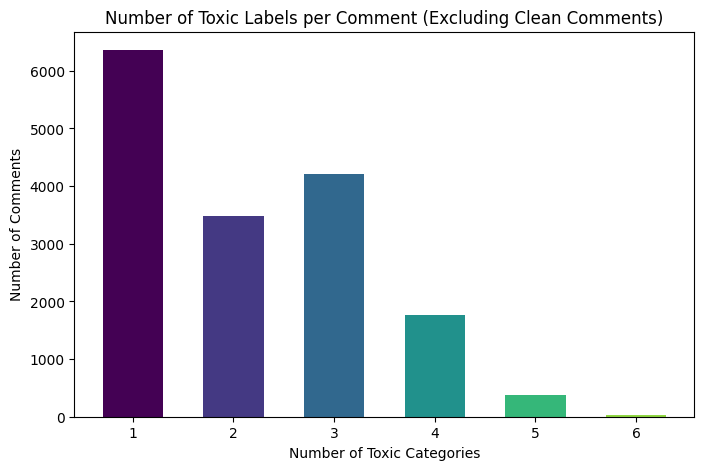

In [9]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

df['label_count'] = df[label_cols].sum(axis=1).astype(int)

counts = df['label_count'].value_counts().sort_index()

# Filter out comments with 0 toxic labels
nonzero = df[df['label_count'] > 0]

# Count the number of comments for each label_count
counts_nonzero = nonzero['label_count'].value_counts().sort_index()

cmap = plt.get_cmap("viridis")

# Generate colors for each bar
colors = [cmap(i / len(counts_nonzero)) for i in range(len(counts_nonzero))]

# Plot
plt.figure(figsize=(8,5))
plt.bar(counts_nonzero.index, counts_nonzero.values, width=0.6, color=colors)
plt.xticks(counts_nonzero.index)  # force exact integer ticks
plt.xlabel("Number of Toxic Categories")
plt.ylabel("Number of Comments")
plt.title("Number of Toxic Labels per Comment (Excluding Clean Comments)")
plt.show()


## Number of Toxic Labels per Comment
- The majority of comments have 0 toxic labels (i.e., clean).
- Among toxic comments:
    - 1–3 labels are most common.
    - 4–6 labels are very rare (<1%).
- Most toxic comments express one or two types of toxicity, but a small minority are extremely toxic across multiple dimensions.
- This reinforces the class imbalance and indicates that multi-label dependencies exist (some labels co-occur frequently).

## Since the data is highly imbalanced with multiple labels, macro F1 is the strongest choice to measure outcomes rather than pure accuracy.

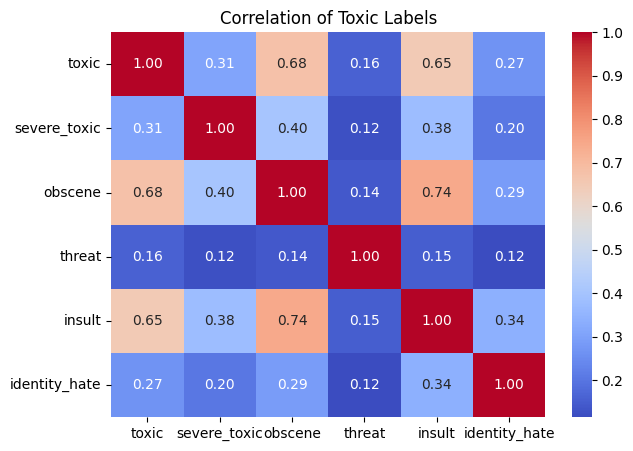

In [10]:
# Compute the correlation matrix between labels
corr = df[label_cols].corr()

# Plot as heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Toxic Labels")
plt.show()


Label Co-Occurrence (Correlation Heatmap)

- Results
    - obscene ↔ insult: 0.74 (strongest correlation)
    - obscene ↔ toxic: 0.68
    - insult ↔ toxic: 0.65
- Toxic behaviors overlap; especially between obscene and insult, which often appear together.
- This suggests that models should share features between labels or be designed to handle joint patterns of toxicity, rather than treating each label as independent.

## Phase 2: Text Preprocessing

In this phase, we prepare the comments for modeling by cleaning and standardizing the text. 
The steps include:

1. **Lowercasing and punctuation removal**  
   Converts all text to lowercase and removes punctuation/special characters to reduce noise.

2. **Stopword removal**  
   Removes common English words (like “the”, “and”, “is”) that do not carry meaningful information for toxicity detection.

3. **Lemmatization**  
   Converts words to their base form (e.g., “running” → “run”) so different forms of the same word are treated consistently.  

The final result is stored in the `processed_text` column, which will be used as input for the model.

**Note for future users:**  
This notebook uses [spaCy](https://spacy.io/) for lemmatization. If running in a new environment, install spaCy and download the English model once:

```bash
pip install spacy
python -m spacy download en_core_web_sm


In [11]:

# Step 1: Lowercase and remove punctuation
df['clean_text'] = df['comment_text'].str.lower().apply(lambda x: re.sub(r'[^\w\s]', '', x))

# Quick check
df[['comment_text', 'clean_text']].head(3)


,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation\nwhy the edits made under my usern...
1,D'aww! He matches this background colour I'm s...,daww he matches this background colour im seem...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really not trying to edit war its j...


In [12]:
# Download stopword list (only needs to be done once)
# nltk.download('stopwords')  # Uncomment if running in a new environment

# Define stopword set
stop_words = set(stopwords.words('english'))

# Remove stopwords from clean_text
df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

# Quick check
df[['comment_text', 'clean_text']].head(3)

,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,daww matches background colour im seemingly st...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really trying edit war guy constant...


In [ ]:

# Load English model (only needs to be done once)
nlp = spacy.load("en_core_web_sm")  # Uncomment if running in a new environment

# Generator function to yield processed text
def lemmatize_and_remove_stopwords_pipe(texts, n_process=4):
    results = []
    for doc in nlp.pipe(texts, n_process=n_process, batch_size=200):
        lemmas = [token.lemma_.lower() for token in doc 
                  if not token.is_stop and token.is_alpha]
        results.append(" ".join(lemmas))
    return results

df["processed_text"] = lemmatize_and_remove_stopwords_pipe(
    df["clean_text"],
    n_process=4  # change to 2 if CPU gets loud
)

df[["clean_text", "processed_text"]].head(3)


,clean_text,processed_text
0,explanation edits made username hardcore metal...,explanation edit username hardcore metallica f...
1,daww matches background colour im seemingly st...,daww match background colour m seemingly stuck...
2,hey man im really trying edit war guy constant...,hey man m try edit war guy constantly remove r...


In [20]:
df.to_csv("../data/processed_text.csv", index=False)